[H1 γ=0.0] ulmm_amsterdam-netherlands.pkl :: van :: ['DA', 'AD']
[H1 γ=0.0] ulmm_barcelona-spain.pkl :: van :: ['DA', 'AD']
[H1 γ=0.0] ulmm_new-york-city-new-york-usa.pkl :: van :: ['DA', 'AD']
[H1 γ=0.0] ulmm_paris-france.pkl :: van :: ['DA', 'AD']
[H1 γ=0.0] ulmm_seattle-washington-usa.pkl :: van :: ['DA', 'AD']


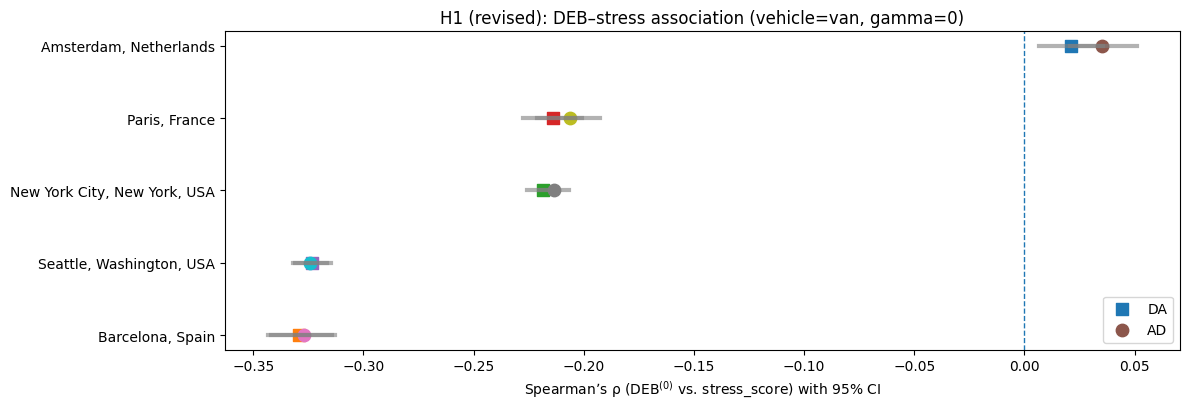

In [4]:
import math, pickle, os
from pathlib import Path
from typing import Dict, Iterable, List, Tuple
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    import statsmodels.api as sm
except Exception:
    sm = None

from scipy.stats import spearmanr, norm
try:
    from statsmodels.stats.sandwich_covariance import cov_hc1
except Exception:
    cov_hc1 = None

# ----------------------------
# CONFIG
# ----------------------------
PICKLES_DIR = Path("ulmm_pickles")
OUT_DIR     = Path("h1_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

VEHICLE       = "van"             # or "cargo_bike"
ORIENTATIONS  = ["DA","AD"]
GAMMA_DEB     = 0.0               # <-- no damping in DEB for H1 (raw pair-weighted)
TOP_Q         = 0.90              # top decile = high DEB
Q_LANES       = 0.80              # stress thresholds
Q_COMM        = 0.80
COMM_HOPS     = 2
COMM_DECAY_B  = 1.0
BOOTSTRAP_B   = 1000
SEED          = 42
SAVE_PER_EDGE = False

# ----------------------------
# Helpers (names kept consistent)
# ----------------------------
def _city_slug_from_path(p: Path) -> str:
    return p.stem.replace("ulmm_","")

def _discover_pickles() -> List[Path]:
    return sorted(PICKLES_DIR.glob("ulmm_*.pkl"))

def _zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    mu = np.nanmean(x); sd = np.nanstd(x)
    return (x - mu) / (sd if sd > 0 else 1.0)

def _safe_log1p(x): 
    return np.log1p(np.maximum(np.asarray(x,float), 0.0))

def load_ulmm(pkl_path: Path) -> Dict:
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

def collapse_to_digraph(Gm: nx.MultiDiGraph, vehicle: str) -> Tuple[nx.DiGraph, Dict[Tuple[int,int],Dict]]:
    w_key  = f"c_eff_{vehicle}"
    phi_k  = f"phi_{vehicle}"
    keep_attrs = [
        "length", "c_base", w_key, phi_k,
        "f_lanes_scarcity", "f_restricted_access", "f_bus_only",
        "f_pedestrian_zone", "f_no_stopping", "f_slope"
    ]
    best = {}
    for u, v, k, d in Gm.edges(keys=True, data=True):
        d_w = float(d.get(w_key, d.get("c_base", np.inf)))
        key = (u, v)
        carry = {a: float(d.get(a, np.nan)) for a in keep_attrs}
        if key not in best or d_w < best[key][0]:
            best[key] = (d_w, carry)
    G = nx.DiGraph()
    eattr = {}
    for (u, v), (w_min, carry) in best.items():
        G.add_edge(u, v)
        length = float(carry.get("length", np.nan))
        if not np.isfinite(length) or length <= 0:
            length = 1.0
        eattr[(u, v)] = dict(carry)
        eattr[(u, v)]["weight"] = float(w_min)
        eattr[(u, v)]["length"] = length
    nx.set_edge_attributes(G, {e: {"weight": a["weight"]} for e, a in eattr.items()})
    return G, eattr

def oriented_sets(ulmm: Dict, orientation: str):
    ddf = ulmm["demand"]; adf = ulmm["access"]
    w_d = dict(zip(ddf["i_node"].astype(int), ddf["w"].astype(float)))
    alpha_a = dict(zip(adf["i_node"].astype(int), np.ones(len(adf), float)))
    if orientation.upper() == "DA":
        sources = list(dict.fromkeys(ddf["i_node"].astype(int).tolist()))
        targets = list(dict.fromkeys(adf["i_node"].astype(int).tolist()))
        sw = {int(n): float(w_d.get(int(n), 0.0)) for n in sources}
        tw = {int(n): float(alpha_a.get(int(n), 1.0)) for n in targets}
    else:
        sources = list(dict.fromkeys(adf["i_node"].astype(int).tolist()))
        targets = list(dict.fromkeys(ddf["i_node"].astype(int).tolist()))
        sw = {int(n): float(alpha_a.get(int(n), 1.0)) for n in sources}
        tw = {int(n): float(w_d.get(int(n), 0.0)) for n in targets}
    sources = [s for s in sources if s is not None]
    targets = [t for t in targets if t is not None]
    return sources, targets, sw, tw

def edge_deb_pairweighted(G, sources, targets, sw, tw, weight_attr="weight"):
    EB = {e: 0.0 for e in G.edges()}
    Tset = set(targets); eps = 1e-12
    import heapq
    for s in sources:
        if s not in G: continue
        S_stack=[]; P={v:[] for v in G.nodes()}
        sigma={v:0.0 for v in G.nodes()}; dist={v:math.inf for v in G.nodes()}
        sigma[s]=1.0; dist[s]=0.0
        Q=[]; heapq.heappush(Q,(0.0,s))
        while Q:
            du,u=heapq.heappop(Q)
            if du>dist[u]: continue
            S_stack.append(u)
            for v in G.successors(u):
                w_uv = float(G[u][v].get(weight_attr, math.inf))
                alt  = dist[u] + w_uv
                if alt < dist[v] - eps:
                    dist[v]=alt; heapq.heappush(Q,(alt,v))
                    sigma[v]=sigma[u]; P[v]=[u]
                elif abs(alt - dist[v]) <= eps:
                    sigma[v]+=sigma[u]; P[v].append(u)
        delta={v:0.0 for v in G.nodes()}
        s_w = float(sw.get(s, 0.0))
        t_weight = (lambda x: float(tw.get(x,0.0)) if x in Tset else 0.0)
        while S_stack:
            w = S_stack.pop()
            coeff = t_weight(w) + delta[w]
            sig_w = sigma[w] if sigma[w]>0 else 1.0
            for v in P[w]:
                c = (sigma[v]/sig_w)*coeff
                if (v,w) in EB: EB[(v,w)] += s_w*c
                delta[v] += c
    return EB

def _smoothed_node_demand_density(G, eattr, ulmm, hops=2, beta=1.0) -> Dict[int, float]:
    curb_len = {n: 0.0 for n in G.nodes()}
    for (u, v), a in eattr.items():
        L = float(a.get("length", 0.0))
        curb_len[u] += L; curb_len[v] += L
    ddf = ulmm["demand"]
    node_w = ddf.groupby(ddf["i_node"].astype(int))["w"].sum().to_dict()
    density = {}
    for n in G.nodes():
        seen = {n: 0}
        frontier = [n]
        for h in range(1, hops + 1):
            nxt = []
            for u in frontier:
                for v in set(G.predecessors(u)).union(G.successors(u)):
                    if v not in seen:
                        seen[v] = h
                        nxt.append(v)
            frontier = nxt
        agg = 0.0
        for v, h in seen.items():
            wv = float(node_w.get(v, 0.0))
            agg += wv / ((1.0 + h) ** beta)
        denom = max(curb_len.get(n, 0.0), 1.0)
        density[n] = agg / denom
    return density

def build_stress_proxy(G, eattr, ulmm, q_lanes=0.80, q_comm=0.80):
    dens = _smoothed_node_demand_density(G, eattr, ulmm, COMM_HOPS, COMM_DECAY_B)
    rows=[]
    for (u,v) in G.edges():
        a=eattr[(u,v)]
        rows.append({
            "u":u,"v":v,
            "lanes_scarcity": float(a.get("f_lanes_scarcity", np.nan)),
            "comm_intensity": max(float(dens.get(u,0.0)), float(dens.get(v,0.0))),
            "length": float(a.get("length", np.nan)),
            "phi": float(a.get("phi", np.nan)),
        })
    edf = pd.DataFrame(rows)
    # thresholds
    L = edf["lanes_scarcity"].replace([np.inf,-np.inf],np.nan)
    C = edf["comm_intensity"].replace([np.inf,-np.inf],np.nan)
    thr_L = np.nanquantile(L, q_lanes) if L.notna().any() else np.inf
    thr_C = np.nanquantile(C, q_comm)  if C.notna().any() else np.inf
    S = ((L>=thr_L) & (C>=thr_C)).astype(int)
    # rank-based continuous stress
    Lr = L.rank(pct=True, method="average")
    Cr = C.rank(pct=True, method="average")
    stress_score = 0.5*Lr + 0.5*Cr
    edf["stress_score"] = stress_score.values
    return edf, S

def lift_or(y, h, B=1000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y,int); h = np.asarray(h,int)
    def cont(yy, hh):
        a = int(((hh==1)&(yy==1)).sum())
        b = int(((hh==1)&(yy==0)).sum())
        c = int(((hh==0)&(yy==1)).sum())
        d = int(((hh==0)&(yy==0)).sum())
        return a,b,c,d
    pS_all = y.mean() if len(y) else np.nan
    pS_high= y[h==1].mean() if (h==1).any() else np.nan
    lift   = (pS_high/pS_all) if pS_all>0 else np.nan
    a,b,c,d = cont(y,h)
    or_hat  = ((a+0.5)/(b+0.5))/((c+0.5)/(d+0.5))
    # bootstrap
    n=len(y); bootsL=[]; bootsOR=[]
    for _ in range(B):
        ii=rng.integers(0,n,size=n); yy=y[ii]; hh=h[ii]
        p_all=yy.mean(); p_high=yy[hh==1].mean() if (hh==1).any() else np.nan
        bootsL.append((p_high/p_all) if p_all>0 else np.nan)
        a,b,c,d = cont(yy,hh)
        bootsOR.append(((a+0.5)/(b+0.5))/((c+0.5)/(d+0.5)))
    loL,hiL = np.nanpercentile(bootsL,[2.5,97.5])
    loO,hiO = np.nanpercentile(bootsOR,[2.5,97.5])
    return {"pS":float(pS_all),"pS_high":float(pS_high),
            "Lift":float(lift),"Lift_lo":float(loL),"Lift_hi":float(hiL),
            "OR":float(or_hat),"OR_lo":float(loO),"OR_hi":float(hiO)}

def spearman_ci(x, y, B=1000, seed=42):
    x = np.asarray(x,float); y = np.asarray(y,float)
    mask = np.isfinite(x) & np.isfinite(y)
    x=x[mask]; y=y[mask]
    rho, _ = spearmanr(x,y)
    rng=np.random.default_rng(seed); boots=[]
    n=len(x)
    for _ in range(B):
        ii=rng.integers(0,n,size=n)
        rr,_=spearmanr(x[ii], y[ii]); boots.append(rr)
    lo,hi=np.nanpercentile(boots,[2.5,97.5])
    return float(rho), float(lo), float(hi)

def logistic_glm_S_on_DEB(df: pd.DataFrame):
    """
    Logit(S) ~ z(DEB) + z(log(1+length)) with robust s.e. (HC1 if available).
    """
    if sm is None:
        return {"coef_DEB": np.nan, "se_DEB": np.nan, "p_DEB": np.nan, "note": "statsmodels not installed"}

    X = pd.DataFrame({
        "const": 1.0,
        "zDEB": _zscore(df["DEB"].astype(float).values),
        "zlen": _zscore(_safe_log1p(df["length"].astype(float).values)),
    })
    y = df["S"].astype(int).values

    try:
        res = sm.Logit(y, X[["const","zDEB","zlen"]]).fit(disp=False, cov_type="HC1")
        return {
            "coef_DEB": float(res.params.get("zDEB", np.nan)),
            "se_DEB":   float(res.bse.get("zDEB", np.nan)),
            "p_DEB":    float(res.pvalues.get("zDEB", np.nan)),
        }
    except TypeError:
        res = sm.Logit(y, X[["const","zDEB","zlen"]]).fit(disp=False)
        coef = float(res.params.get("zDEB", np.nan))
        if cov_hc1 is not None:
            cov = cov_hc1(res)
            se  = float(np.sqrt(np.diag(cov))[list(res.params.index).index("zDEB")])
            p   = float(2 * (1 - norm.cdf(abs(coef / se))))
        else:
            se = float(res.bse.get("zDEB", np.nan))
            p  = float(res.pvalues.get("zDEB", np.nan))
        return {"coef_DEB": coef, "se_DEB": se, "p_DEB": p}
    except Exception as e:
        return {"coef_DEB": np.nan, "se_DEB": np.nan, "p_DEB": np.nan, "note": f"Logit failed: {e}"}

# ----------------------------
# Per-city run (gamma passed; 0.0 => undamped)
# ----------------------------
def run_h1_for_city(pkl_path: Path, vehicle: str, gamma: float, orientations: List[str]) -> pd.DataFrame:
    ulmm = load_ulmm(pkl_path)
    city_name = ulmm["city"]; city_slug = _city_slug_from_path(pkl_path)

    Gm: nx.MultiDiGraph = ulmm["graph"]
    G, eattr = collapse_to_digraph(Gm, vehicle=vehicle)

    theta = ulmm.get("params", {}).get("vehicles", {}).get(vehicle, {}).get("theta", {})
    w_lanes = float(theta.get("lanes_scarcity", 0.0))

    edf_base, S = build_stress_proxy(G, eattr, ulmm, q_lanes=Q_LANES, q_comm=Q_COMM)
    edf_base["S"] = S.values

    results_rows = []
    for xi in orientations:
        sources, targets, sw, tw = oriented_sets(ulmm, xi)
        if not sources or not targets:
            print(f"[WARN] {city_name} / {xi}: empty sources or targets; skipping.")
            continue

        deb_raw = edge_deb_pairweighted(G, sources, targets, sw, tw, weight_attr="weight")

        deb = {}
        for (u, v), val in deb_raw.items():
            phi = float(eattr[(u, v)].get("phi", 0.0))
            fL  = float(eattr[(u, v)].get("f_lanes_scarcity", 0.0))
            # viability-damped φ (gamma=0 -> no damping)
            phi_viab = max(phi - w_lanes * (fL if np.isfinite(fL) else 0.0), 0.0)
            deb[(u, v)] = val * math.exp(-gamma * phi_viab)

        deb_sum = sum(deb.values()) if deb else 1.0
        deb_hat = {e: (v / deb_sum) for e, v in deb.items()}

        edf = edf_base.copy()
        edf["DEB"] = [deb.get((u, v), 0.0) for u, v in zip(edf["u"], edf["v"])]
        edf["DEB_hat"] = [deb_hat.get((u, v), 0.0) for u, v in zip(edf["u"], edf["v"])]

        thr = np.nanquantile(edf["DEB"].values, TOP_Q) if np.any(edf["DEB"].values > 0) else np.nanquantile(edf["DEB_hat"].values, TOP_Q)
        edf["high_DEB"] = (edf["DEB"] >= thr).astype(int)

        stats = lift_or(edf["S"].values, edf["high_DEB"].values, B=BOOTSTRAP_B, seed=SEED)
        glm = logistic_glm_S_on_DEB(edf)

        if SAVE_PER_EDGE:
            out_edges = OUT_DIR / f"h1_edges_{city_slug}_{vehicle}_{xi}.csv"
            edf.to_csv(out_edges, index=False)

        results_rows.append({
            "city": city_name, "slug": city_slug, "vehicle": vehicle,
            "orientation": xi, "gamma": gamma, "n_edges": int(len(edf)),
            "pS": stats["pS"], "pS_high": stats["pS_high"],
            "Lift": stats["Lift"], "Lift_lo": stats["Lift_lo"], "Lift_hi": stats["Lift_hi"],
            "OR": stats["OR"], "OR_lo": stats["OR_lo"], "OR_hi": stats["OR_hi"],
            "GLM_coef_DEB": glm.get("coef_DEB", np.nan),
            "GLM_se_DEB": glm.get("se_DEB", np.nan),
            "GLM_p_DEB": glm.get("p_DEB", np.nan),
        })
    return pd.DataFrame(results_rows)

# convenience: produce both the H1 table AND the Spearman ρ table per city
def run_h1_city_gamma0(pkl_path: Path, vehicle: str, orientations: List[str]):
    ulmm = load_ulmm(pkl_path)
    city_name = ulmm["city"]; city_slug = _city_slug_from_path(pkl_path)
    G, eattr = collapse_to_digraph(ulmm["graph"], vehicle)

    theta = ulmm.get("params", {}).get("vehicles", {}).get(vehicle, {}).get("theta", {})
    w_lanes = float(theta.get("lanes_scarcity", 0.0))

    base, S = build_stress_proxy(G, eattr, ulmm, q_lanes=Q_LANES, q_comm=Q_COMM)
    base["S"] = S.values

    # full H1 table using the standard runner (gamma=0)
    df_city = run_h1_for_city(pkl_path, vehicle, gamma=GAMMA_DEB, orientations=orientations)

    # continuous association (Spearman ρ)
    rho_rows=[]
    for xi in orientations:
        s,t,sw,tw = oriented_sets(ulmm, xi)
        if not s or not t: 
            continue
        deb_raw = edge_deb_pairweighted(G, s, t, sw, tw, weight_attr="weight")
        base[f"DEB0_{xi}"] = [deb_raw.get((u,v),0.0) for u,v in zip(base["u"], base["v"])]
        rho, lo, hi = spearman_ci(base[f"DEB0_{xi}"].values, base["stress_score"].values, B=BOOTSTRAP_B, seed=SEED)
        rho_rows.append({
            "city": city_name, "slug": city_slug,
            "vehicle": vehicle, "orientation": xi,
            "rho": rho, "rho_lo": lo, "rho_hi": hi
        })
    df_rho = pd.DataFrame(rho_rows)
    return df_city, df_rho

# ----------------------------
# Pooled FE GLM (wrapper for γ=0)
# ----------------------------
def pooled_fe_glm(pickle_paths: List[Path], vehicle: str, gamma: float, orientation: str) -> pd.DataFrame:
    if sm is None:
        return pd.DataFrame([{"note":"statsmodels not installed; pooled FE GLM skipped"}])

    rows = []
    for p in pickle_paths:
        ulmm = load_ulmm(p); city_slug = _city_slug_from_path(p)
        G, eattr = collapse_to_digraph(ulmm["graph"], vehicle)
        theta = ulmm.get("params", {}).get("vehicles", {}).get(vehicle, {}).get("theta", {})
        w_lanes = float(theta.get("lanes_scarcity", 0.0))

        edf_base, S = build_stress_proxy(G, eattr, ulmm, q_lanes=Q_LANES, q_comm=Q_COMM)
        edf_base["S"] = S.values

        s,t,sw,tw = oriented_sets(ulmm, orientation)
        if not s or not t: continue
        deb_raw = edge_deb_pairweighted(G, s, t, sw, tw, weight_attr="weight")

        deb={}
        for e, v in deb_raw.items():
            phi = float(eattr[e].get("phi", 0.0))
            fL  = float(eattr[e].get("f_lanes_scarcity", 0.0))
            phi_viab = max(phi - w_lanes*(fL if np.isfinite(fL) else 0.0), 0.0)
            deb[e] = v * math.exp(-gamma * phi_viab)

        edf = edf_base.copy()
        edf["DEB"] = [deb.get((u, v), 0.0) for u, v in zip(edf["u"], edf["v"])]
        edf["city"] = city_slug
        rows.append(edf[["S","DEB","length","city"]])

    if not rows:
        return pd.DataFrame([{"note":"no data for pooled model"}])

    pooled = pd.concat(rows, ignore_index=True)
    dummies = pd.get_dummies(pooled["city"], drop_first=True, dtype=float)
    X = pd.DataFrame({
        "const": 1.0,
        "zDEB": _zscore(pooled["DEB"].astype(float).values),
        "zlen": _zscore(_safe_log1p(pooled["length"].astype(float).values)),
    })
    X = pd.concat([X, dummies], axis=1)
    y = pooled["S"].astype(int).values

    try:
        res = sm.Logit(y, X).fit(disp=False, cov_type="HC1")
        coef, se, pval = float(res.params["zDEB"]), float(res.bse["zDEB"]), float(res.pvalues["zDEB"])
    except TypeError:
        res = sm.Logit(y, X).fit(disp=False)
        try:
            cov = cov_hc1(res) if cov_hc1 is not None else None
            if cov is not None:
                idx = list(res.params.index).index("zDEB")
                se  = float(np.sqrt(np.diag(cov))[idx]); coef = float(res.params["zDEB"])
                pval = float(2*(1-norm.cdf(abs(coef/se))))
            else:
                coef, se, pval = float(res.params["zDEB"]), float(res.bse["zDEB"]), float(res.pvalues["zDEB"])
        except Exception:
            coef, se, pval = float(res.params["zDEB"]), float(res.bse["zDEB"]), float(res.pvalues["zDEB"])

    return pd.DataFrame([{
        "vehicle": vehicle, "orientation": orientation, "gamma": gamma,
        "coef_DEB": coef, "se_DEB": se, "p_DEB": pval,
        "n_edges": int(len(y)), "n_cities": int(dummies.shape[1] + 1),
    }])

def pooled_fe_glm_gamma0(pickle_paths: List[Path], vehicle: str, orientation: str) -> pd.DataFrame:
    return pooled_fe_glm(pickle_paths, vehicle=vehicle, gamma=GAMMA_DEB, orientation=orientation)

# ----------------------------
# Matched difference within phi bins
# ----------------------------
def matched_diff_by_phi(df_edges: pd.DataFrame, bins=5):
    q = pd.qcut(df_edges["phi"].rank(method="first"), bins, labels=False, duplicates="drop")
    df_edges = df_edges.assign(phi_bin=q)
    diffs=[]
    for b in sorted(df_edges["phi_bin"].dropna().unique()):
        sub = df_edges[df_edges["phi_bin"]==b]
        if len(sub)<10: continue
        pH = sub.loc[sub["high_DEB0"]==1,"S"].mean()
        pL = sub.loc[sub["high_DEB0"]==0,"S"].mean()
        diffs.append({"phi_bin":int(b), "diff": float(pH-pL), "n":int(len(sub))})
    return pd.DataFrame(diffs)

# ----------------------------
# Main
# ----------------------------
pickles = _discover_pickles()

all_city = []; all_rho = []
for p in pickles:
    print(f"[H1 γ={GAMMA_DEB}] {p.name} :: {VEHICLE} :: {ORIENTATIONS}")
    df_city, df_rho = run_h1_city_gamma0(p, VEHICLE, ORIENTATIONS)
    if not df_city.empty:
        df_city.to_csv(OUT_DIR/f"h1_gamma0_summary_{_city_slug_from_path(p)}_{VEHICLE}.csv", index=False)
    if not df_rho.empty:
        df_rho.to_csv(OUT_DIR/f"h1_gamma0_rho_{_city_slug_from_path(p)}_{VEHICLE}.csv", index=False)
    all_city.append(df_city); all_rho.append(df_rho)

if any(len(df) for df in all_city):
    H1_SUM = pd.concat(all_city, ignore_index=True)
    H1_SUM.to_csv(OUT_DIR/f"h1_gamma0_summary_all_{VEHICLE}.csv", index=False)

if any(len(df) for df in all_rho):
    RHO_SUM = pd.concat(all_rho, ignore_index=True)
    RHO_SUM.to_csv(OUT_DIR/f"h1_gamma0_rho_all_{VEHICLE}.csv", index=False)

# pooled FE GLM
if sm is not None and len(pickles) > 0:
    pooled_rows=[]
    for xi in ORIENTATIONS:
        pooled_rows.append(pooled_fe_glm_gamma0(pickles, VEHICLE, xi))
    POOLED = pd.concat(pooled_rows, ignore_index=True)
    POOLED.to_csv(OUT_DIR/f"h1_gamma0_pooled_fe_{VEHICLE}.csv", index=False)

# ----------------------------
# FIGURE 1: Spearman ρ forest (per city, per orientation) for DEB0
# ----------------------------
if any(len(df) for df in all_rho):
    RHO_SUM = pd.concat(all_rho, ignore_index=True)
    order = (RHO_SUM.groupby("city")["rho"].mean().sort_values().index.tolist())
    fig, ax = plt.subplots(figsize=(12,4.2))
    ymap = {c:i for i,c in enumerate(order)}
    # plot CI bars and points; give labels only once for legend
    first_da = True; first_ad = True
    for xi, marker in [("DA","s"),("AD","o")]:
        sub = RHO_SUM[RHO_SUM["orientation"]==xi]
        for _,r in sub.iterrows():
            y = ymap[r["city"]]
            ax.plot([r["rho_lo"], r["rho_hi"]], [y,y], lw=3, alpha=0.6, color="0.5")
            if xi=="DA":
                ax.scatter(r["rho"], y, marker=marker, s=80, label="DA" if first_da else None)
                first_da = False
            else:
                ax.scatter(r["rho"], y, marker=marker, s=80, label="AD" if first_ad else None)
                first_ad = False
    ax.axvline(0.0, ls="--", lw=1)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
    ax.set_xlabel("Spearman’s ρ (DEB$^{(0)}$ vs. stress_score) with 95% CI")
    ax.set_title(f"H1 (revised): DEB–stress association (vehicle={VEHICLE}, gamma=0)")
    ax.legend(loc="lower right", frameon=True)
    fig.tight_layout()
    fig.savefig(OUT_DIR/f"h1_gamma0_rho_forest_{VEHICLE}.png", dpi=200)

# ----------------------------
# FIGURE 2: Matched differences within phi bins (example per city, AD)
# ----------------------------
for p in pickles:
    slug = _city_slug_from_path(p)
    ulmm = load_ulmm(p); G,eattr = collapse_to_digraph(ulmm["graph"], VEHICLE)
    base,S = build_stress_proxy(G, eattr, ulmm, q_lanes=Q_LANES, q_comm=Q_COMM); base["S"]=S.values
    s,t,sw,tw = oriented_sets(ulmm, "AD")
    if not s or not t: 
        continue
    deb_raw = edge_deb_pairweighted(G, s,t, sw,tw, weight_attr="weight")
    base["DEB0"]    = [deb_raw.get((u,v),0.0) for u,v in zip(base["u"], base["v"])]
    thr = np.nanquantile(base["DEB0"].values, TOP_Q) if (base["DEB0"]>0).any() else np.inf
    base["high_DEB0"] = (base["DEB0"]>=thr).astype(int)
    md = matched_diff_by_phi(base, bins=5)
    if md.empty: 
        continue
    plt.figure(figsize=(4.8,3.2))
    plt.bar(md["phi_bin"].astype(int), md["diff"])
    plt.axhline(0, ls="--", lw=1)
    plt.xlabel("φ bin (quintiles)"); plt.ylabel("Δ stress prevalence (high-DEB0 minus others)")
    plt.title(f"Matched Δ within φ bins — {slug} (AD)")
    plt.tight_layout()
    plt.savefig(OUT_DIR/f"h1_gamma0_matched_{slug}_{VEHICLE}_AD.png", dpi=200)

In [7]:
import pandas as pd
from scipy.stats import binomtest

rho = pd.read_csv("h1_outputs/h1_gamma0_rho_all_van.csv")
summ = pd.read_csv("h1_outputs/h1_gamma0_summary_all_van.csv")

tab = summ.merge(
    rho[["city","orientation","rho","rho_lo","rho_hi"]],
    on=["city","orientation"],
    how="left"
)

tab["rho_ci"] = tab.apply(lambda r: f"{r['rho']:.3f} [{r['rho_lo']:.3f}, {r['rho_hi']:.3f}]", axis=1)
tab["beta_p"] = tab.apply(lambda r: f"{r['GLM_coef_DEB']:.3f} (p={r['GLM_p_DEB']:.1e})", axis=1)
tab["OR_ci"]  = tab.apply(lambda r: f"{r['OR']:.2f} [{r['OR_lo']:.2f}, {r['OR_hi']:.2f}]", axis=1)

final = (tab[["city","orientation","rho_ci","beta_p","OR_ci"]]
         .rename(columns={"city":"City","orientation":"Orient.",
                          "rho_ci":"Spearman $\\rho$ (95\\% CI)",
                          "beta_p":"Logit $\\beta_{\\text{DEB}}$ (p-value)",
                          "OR_ci":"Odds ratio (95\\% CI)"})
         .sort_values(["City","Orient."]))

out_tex = "h1_outputs/h1_gamma0_results_table.tex"
final.to_latex(out_tex, index=False, escape=False)

neg_and_sig = ((summ["GLM_coef_DEB"]<0) & (summ["GLM_p_DEB"]<0.05)).sum()
n = len(summ)
pval = binomtest(neg_and_sig, n, 0.5, alternative="greater").pvalue
print(f"[H1 sign test] negatives={neg_and_sig}/{n}, one-sided p={pval:.3e}")

[H1 sign test] negatives=10/10, one-sided p=9.766e-04


In [2]:
# ==============================
# H1 pooled effect sizes (de-correlated, direction-aligned)
# ==============================

import os, math, pickle
from pathlib import Path
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import spearmanr

try:
    from sklearn.metrics import roc_auc_score, average_precision_score
except Exception:
    roc_auc_score = None
    average_precision_score = None

PICKLES_DIR = Path("ulmm_pickles")
OUT_DIR      = Path("h1_outputs")
OUT_DIR_REV  = Path("h1_outputs_revised")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR_REV.mkdir(parents=True, exist_ok=True)

VEHICLE       = "van"             # or "cargo_bike"
ORIENTATIONS  = ["DA", "AD"]
TOP_Q         = 0.90              # for Lift@top-decile per slice
COMM_HOPS     = 2
COMM_DECAY_B  = 1.0

# ---------- small utils ----------
def _discover_pickles() -> List[Path]:
    return sorted(PICKLES_DIR.glob("ulmm_*.pkl"))

def load_ulmm(pkl_path: Path) -> Dict:
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

def _zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, float)
    mu = np.nanmean(x); sd = np.nanstd(x)
    return (x - mu) / (sd if sd > 0 else 1.0)

def _safe_auc(y_true, y_score):
    if roc_auc_score is None:
        return np.nan
    y = np.asarray(y_true, int)
    s = np.asarray(y_score, float)
    if (y.sum() == 0) or (y.sum() == len(y)):
        return np.nan
    return float(roc_auc_score(y, s))

def _safe_ap(y_true, y_score):
    if average_precision_score is None:
        return np.nan
    y = np.asarray(y_true, int)
    s = np.asarray(y_score, float)
    if (y.sum() == 0) or (y.sum() == len(y)):
        return np.nan
    return float(average_precision_score(y, s))

# ---------- graph helpers (as in your code) ----------
def collapse_to_digraph(Gm: nx.MultiDiGraph, vehicle: str) -> Tuple[nx.DiGraph, Dict[Tuple[int,int],Dict]]:
    w_key  = f"c_eff_{vehicle}"
    phi_k  = f"phi_{vehicle}"
    keep_attrs = [
        "length", "c_base", w_key, phi_k,
        "f_lanes_scarcity", "f_restricted_access", "f_bus_only",
        "f_pedestrian_zone", "f_no_stopping", "f_slope"
    ]
    best = {}
    for u, v, k, d in Gm.edges(keys=True, data=True):
        d_w = float(d.get(w_key, d.get("c_base", np.inf)))
        key = (u, v)
        carry = {a: float(d.get(a, np.nan)) for a in keep_attrs}
        if key not in best or d_w < best[key][0]:
            best[key] = (d_w, carry)
    G = nx.DiGraph()
    eattr = {}
    for (u, v), (w_min, carry) in best.items():
        G.add_edge(u, v)
        length = float(carry.get("length", np.nan))
        if not np.isfinite(length) or length <= 0:
            length = 1.0
        eattr[(u, v)] = dict(carry)
        eattr[(u, v)]["weight"] = float(w_min)
        eattr[(u, v)]["length"] = length
        eattr[(u, v)]["phi"] = float(carry.get(phi_k, np.nan))
    nx.set_edge_attributes(G, {e: {"weight": a["weight"]} for e, a in eattr.items()})
    return G, eattr

def oriented_sets(ulmm: Dict, orientation: str):
    ddf = ulmm["demand"]; adf = ulmm["access"]
    w_d = dict(zip(ddf["i_node"].astype(int), ddf["w"].astype(float)))
    alpha_a = dict(zip(adf["i_node"].astype(int), np.ones(len(adf), float)))
    if orientation.upper() == "DA":
        sources = list(dict.fromkeys(ddf["i_node"].astype(int).tolist()))
        targets = list(dict.fromkeys(adf["i_node"].astype(int).tolist()))
        sw = {int(n): float(w_d.get(int(n), 0.0)) for n in sources}
        tw = {int(n): float(alpha_a.get(int(n), 1.0)) for n in targets}
    else:
        sources = list(dict.fromkeys(adf["i_node"].astype(int).tolist()))
        targets = list(dict.fromkeys(ddf["i_node"].astype(int).tolist()))
        sw = {int(n): float(alpha_a.get(int(n), 1.0)) for n in sources}
        tw = {int(n): float(w_d.get(int(n), 0.0)) for n in targets}
    sources = [s for s in sources if s is not None]
    targets = [t for t in targets if t is not None]
    return sources, targets, sw, tw

def edge_deb_pairweighted(G, sources, targets, sw, tw, weight_attr="weight"):
    EB = {e: 0.0 for e in G.edges()}
    Tset = set(targets); eps = 1e-12
    import heapq
    for s in sources:
        if s not in G: continue
        S_stack=[]; P={v:[] for v in G.nodes()}
        sigma={v:0.0 for v in G.nodes()}; dist={v:math.inf for v in G.nodes()}
        sigma[s]=1.0; dist[s]=0.0
        Q=[]; heapq.heappush(Q,(0.0,s))
        while Q:
            du,u=heapq.heappop(Q)
            if du>dist[u]: continue
            S_stack.append(u)
            for v in G.successors(u):
                w_uv = float(G[u][v].get(weight_attr, math.inf))
                alt  = dist[u] + w_uv
                if alt < dist[v] - eps:
                    dist[v]=alt; heapq.heappush(Q,(alt,v))
                    sigma[v]=sigma[u]; P[v]=[u]
                elif abs(alt - dist[v]) <= eps:
                    sigma[v]+=sigma[u]; P[v].append(u)
        delta={v:0.0 for v in G.nodes()}
        s_w = float(sw.get(s, 0.0))
        t_weight = (lambda x: float(tw.get(x,0.0)) if x in Tset else 0.0)
        while S_stack:
            w = S_stack.pop()
            coeff = t_weight(w) + delta[w]
            sig_w = sigma[w] if sigma[w]>0 else 1.0
            for v in P[w]:
                c = (sigma[v]/sig_w)*coeff
                if (v,w) in EB: EB[(v,w)] += s_w*c
                delta[v] += c
    return EB

# ---------- demand density & stress proxy ----------
def _smoothed_node_demand_density(G: nx.DiGraph, eattr: Dict, ulmm: Dict, hops=2, beta=1.0) -> Dict[int, float]:
    curb_len = {n: 0.0 for n in G.nodes()}
    for (u, v), a in eattr.items():
        L = float(a.get("length", 0.0))
        curb_len[u] += L; curb_len[v] += L
    ddf = ulmm["demand"]
    node_w = ddf.groupby(ddf["i_node"].astype(int))["w"].sum().to_dict()
    density = {}
    for n in G.nodes():
        seen = {n: 0}
        frontier = [n]
        for h in range(1, hops + 1):
            nxt = []
            for u in frontier:
                for v in set(G.predecessors(u)).union(G.successors(u)):
                    if v not in seen:
                        seen[v] = h
                        nxt.append(v)
            frontier = nxt
        agg = 0.0
        for v, h in seen.items():
            wv = float(node_w.get(v, 0.0))
            agg += wv / ((1.0 + h) ** beta)
        denom = max(curb_len.get(n, 0.0), 1.0)
        density[n] = agg / denom
    return density

def build_base_edge_df(G: nx.DiGraph, eattr: Dict, ulmm: Dict) -> pd.DataFrame:
    dens = _smoothed_node_demand_density(G, eattr, ulmm, hops=COMM_HOPS, beta=COMM_DECAY_B)
    rows=[]
    for (u,v) in G.edges():
        a=eattr[(u,v)]
        lanes = float(a.get("f_lanes_scarcity", np.nan))
        comm  = max(float(dens.get(u,0.0)), float(dens.get(v,0.0)))
        length= float(a.get("length", np.nan))
        rows.append({"u":u,"v":v,"lanes_scarcity":lanes,"comm_intensity":comm,"length":length})
    edf = pd.DataFrame(rows)
    Lr = edf["lanes_scarcity"].replace([np.inf,-np.inf],np.nan).rank(pct=True, method="average")
    Cr = edf["comm_intensity"].replace([np.inf,-np.inf],np.nan).rank(pct=True, method="average")
    edf["stress_score"] = 0.5*Lr + 0.5*Cr
    # discrete S for reference (80/80)
    qL = np.nanquantile(edf["lanes_scarcity"], 0.80) if edf["lanes_scarcity"].notna().any() else np.inf
    qC = np.nanquantile(edf["comm_intensity"], 0.80) if edf["comm_intensity"].notna().any() else np.inf
    edf["S"] = ((edf["lanes_scarcity"]>=qL) & (edf["comm_intensity"]>=qC)).astype(int)
    # varrho proxy for orthogonalization (same as comm)
    edf["varrho"] = edf["comm_intensity"].values
    return edf

def orthogonalize_stress_within_city(edf_city: pd.DataFrame) -> pd.DataFrame:
    df = edf_city.copy()
    zvar = _zscore(df["varrho"].values)
    zlen = _zscore(np.log1p(df["length"].values))
    X = np.vstack([np.ones(len(df)), zvar, zvar**2, zvar**3, zlen]).T
    y = df["stress_score"].values.astype(float)
    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        yhat = X @ beta
    except Exception:
        yhat = np.nanmean(y) * np.ones_like(y)
    df["s_perp"] = y - yhat
    thr = np.nanquantile(df["s_perp"], 0.90)
    df["S_perp"] = (df["s_perp"] >= thr).astype(int)
    return df

# ---------- collector ----------
def collect_edges_with_scores(pkl_path: Path, vehicle: str, orientations: List[str]) -> pd.DataFrame:
    ulmm = load_ulmm(pkl_path); city = ulmm["city"]
    Gm: nx.MultiDiGraph = ulmm["graph"]
    G, eattr = collapse_to_digraph(Gm, vehicle=vehicle)

    base = build_base_edge_df(G, eattr, ulmm)
    base = orthogonalize_stress_within_city(base)
    base["city"] = str(city)

    slices = []
    for xi in orientations:
        s, t, sw, tw = oriented_sets(ulmm, xi)
        if not s or not t: 
            continue
        # weighted
        deb_w = edge_deb_pairweighted(G, s, t, sw, tw, weight_attr="weight")
        # unweighted
        sw_u = {k: 1.0 for k in sw.keys()}
        tw_u = {k: 1.0 for k in tw.keys()}
        deb_u = edge_deb_pairweighted(G, s, t, sw_u, tw_u, weight_attr="weight")

        df = base.copy()
        df["orientation"] = xi
        df["DEB_w_raw"] = [deb_w.get((u,v), 0.0) for u,v in zip(df["u"], df["v"])]
        df["DEB_u_raw"] = [deb_u.get((u,v), 0.0) for u,v in zip(df["u"], df["v"])]
        slices.append(df)

    return pd.concat(slices, ignore_index=True) if slices else pd.DataFrame()

# ---------- per-slice metrics and pooled aggregation ----------
def _direction_aligned_z(col_score: pd.Series, stress: pd.Series, group: pd.Series) -> pd.Series:
    """
    Within each city×orientation slice:
      1) z-score the score
      2) compute Spearman rho between score and stress; if rho<0 flip sign.
    """
    z = col_score.groupby(group).transform(lambda s: pd.Series(_zscore(s.values), index=s.index))
    # sign alignment
    aligned = []
    for key, sub in pd.DataFrame({"z": z, "stress": stress, "g": group}).groupby("g"):
        try:
            rho, _ = spearmanr(sub["z"].values, sub["stress"].values)
        except Exception:
            rho = np.nan
        sign = 1.0 if (np.isnan(rho) or rho >= 0.0) else -1.0
        aligned.append(pd.Series(sign * sub["z"].values, index=sub.index))
    return pd.concat(aligned).sort_index()

def pooled_effect_sizes(df_all: pd.DataFrame) -> pd.DataFrame:
    """
    Compute effect sizes per city×orientation slice, then pool (edge-weighted macro average).
    Outcomes: S and S_perp
    Scores:   DEB (pair-weighted), DEB^U (unweighted)
    """
    if df_all.empty:
        return pd.DataFrame()

    group = df_all["city"].astype(str) + "||" + df_all["orientation"].astype(str)

    # direction-aligned, within-slice z-scores
    df_all["DEB"]   = _direction_aligned_z(df_all["DEB_w_raw"], df_all["stress_score"], group)
    df_all["DEB^U"] = _direction_aligned_z(df_all["DEB_u_raw"], df_all["stress_score"], group)

    rows = []
    for outcome, ycol in [("S (orig.)", "S"), ("S_perp (resid.)", "S_perp")]:
        for score_name in ["DEB", "DEB^U"]:
            # compute per-slice metrics
            per = []
            for key, sub in df_all.groupby(group):
                y = sub[ycol].astype(int).values
                s = sub[score_name].astype(float).values
                n = len(sub)
                if n < 2:
                    continue
                auc = _safe_auc(y, s)
                ap  = _safe_ap(y, s)
                prev= float(y.mean()) if n>0 else np.nan
                # top-decile lift within slice
                thr = np.nanquantile(s, TOP_Q) if n>0 else np.inf
                top_mask = (s >= thr)
                p_top = float(y[top_mask].mean()) if top_mask.any() else np.nan
                lift  = (p_top/prev) if (prev and prev>0 and np.isfinite(p_top)) else np.nan
                per.append({"key":key, "n":n, "AUC":auc, "AP":ap, "AP_base":prev, "Lift":lift})

            if not per:
                rows.append({"Outcome label":outcome,"Score":score_name,
                             "ROC_AUC":np.nan,"PR_AUC":np.nan,"AP_baseline":np.nan,"Lift_top10":np.nan,
                             "N_edges":int(len(df_all)),"N_cities":int(df_all["city"].nunique()),
                             "Orientations":",".join(sorted(df_all["orientation"].unique()))})
                continue

            P = pd.DataFrame(per)
            w = P["n"].astype(float)
            w = w / w.sum()

            def wavg(col): 
                x = P[col].astype(float)
                mask = np.isfinite(x)
                if not mask.any(): 
                    return np.nan
                w_ = (w[mask] / w[mask].sum())
                return float((w_ * x[mask]).sum())

            rows.append({
                "Outcome label": outcome,
                "Score": score_name,
                "ROC_AUC": wavg("AUC"),
                "PR_AUC": wavg("AP"),
                "AP_baseline": wavg("AP_base"),
                "Lift_top10": wavg("Lift"),
                "N_edges": int(len(df_all)),
                "N_cities": int(df_all["city"].nunique()),
                "Orientations": ",".join(sorted(df_all["orientation"].unique()))
            })

    return pd.DataFrame(rows)

# ---------- run ----------
def run_pooled_table(vehicle: str = VEHICLE, orientations: List[str] = ORIENTATIONS) -> pd.DataFrame:
    pickles = _discover_pickles()
    all_df = []
    for p in pickles:
        df_city = collect_edges_with_scores(p, vehicle, orientations)
        if not df_city.empty:
            all_df.append(df_city)
    if not all_df:
        print("[H1 pooled] No data found.")
        return pd.DataFrame()
    df_all = pd.concat(all_df, ignore_index=True)

    # Optional audit:
    # df_all.to_parquet(OUT_DIR / f"h1_edges_with_scores_{vehicle}.parquet", index=False)

    T = pooled_effect_sizes(df_all)

    # CSV + LaTeX
    out_csv = OUT_DIR_REV / f"h1_pooled_effect_sizes_{vehicle}.csv"
    out_tex = OUT_DIR_REV / f"h1_pooled_effect_sizes_{vehicle}.tex"
    T.to_csv(out_csv, index=False)

    T_fmt = T.copy()
    def f3(x): 
        return ("{:.3f}".format(x) if (x==x and np.isfinite(x)) else "--")
    for c in ["ROC_AUC","PR_AUC","AP_baseline","Lift_top10"]:
        T_fmt[c] = T_fmt[c].map(f3)
    with open(out_tex, "w") as f:
        f.write(
            T_fmt[["Outcome label","Score","ROC_AUC","PR_AUC","AP_baseline","Lift_top10"]]
            .rename(columns={"ROC_AUC":"ROC--AUC","PR_AUC":"PR--AUC (AP)","AP_baseline":"AP (baseline)","Lift_top10":"Lift$_{0.1}$"})
            .to_latex(index=False, escape=False)
        )
    print(f"[H1 pooled] wrote {out_csv} and {out_tex}")
    return T

# Execute
_ = run_pooled_table(VEHICLE, ORIENTATIONS)

[H1 pooled] wrote h1_outputs_revised/h1_pooled_effect_sizes_van.csv and h1_outputs_revised/h1_pooled_effect_sizes_van.tex
